In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
import sisl

In [292]:
# sns.set_theme(style="whitegrid", context="paper")

# 2. Fine-tune specific font sizes and behaviors
plt.rcParams.update({
    "font.family": "serif",        # Use serif for a formal/academic look
    "font.size": 14,               # Base font size
    "axes.titlesize": 18,          # Subplot titles (your .set(title=...) calls)
    "axes.labelsize": 16,          # X and Y axis labels
    "xtick.labelsize": 12,         # Size of numbers on X-axis
    "ytick.labelsize": 12,         # Size of numbers on Y-axis
    "legend.fontsize": 14,         # Legend text
    'legend.title_fontsize': 18,
    
    "figure.titlesize": 20,        # Overall figure title
    "axes.labelpad": 10,           # Distance between label and axis
    "mathtext.fontset": "cm",      # Computer Modern (LaTeX look for math)
    "savefig.dpi": 300             # High-res exports
})

In [382]:
BOND = 1.42
OUTER_R = BOND
B = BOND*np.sqrt(3)/2
INNER_R = B

N0 = 3
N1 = 5
KIND = 'zigzag'
R = (0.1, BOND+1e-2)
T = (0.0, -2.7)

BAND_POINTS = np.array([
    [0.0, 0.0, 0.0], # Gamma
    [0.5, 0.0, 0.0], # K_x
])
BAND_NAMES = np.array([
    r"$\Gamma$", # [0, 0, 0]
    r"$\mathrm{K}_x$", # [1/2, 0, 0]
])
NUM_K = 200
NUM_E = 1_000


In [383]:
graphene = sisl.geom.graphene_nanoribbon(width=N1*2, bond=BOND, kind=KIND)
graphene = graphene.tile(N0, 0)

ham = sisl.Hamiltonian(graphene)
ham.construct([R, T])
xyz = ham.xyz
x, y, z = xyz.T

ymin = y.min()
ymax = y.max()
dist_tol = INNER_R
top_idx, = np.where(np.abs(y - ymax) < dist_tol)
bottom_idx, = np.where(np.abs(y - ymin) < dist_tol)
edge_idx = np.concat([top_idx, bottom_idx])
bulk_idx = np.delete(np.arange(ham.na), edge_idx)

In [384]:
bands = sisl.BandStructure(ham, points=BAND_POINTS, divisions=NUM_K, names=BAND_NAMES)
lk, kt, kl = bands.lineark(ticks=True)
kpts = bands.k
eigs = bands.apply.array.eigh()
energies = np.linspace(eigs.min(), eigs.max(), num=NUM_E)
es = ham.eigenstate(kpts)
pdos = es.PDOS(energies).squeeze()
print(pdos.shape)

(60, 1000)


In [385]:
Hks = np.array([ham.Hk(k=kpts[i], format='array') for i in range(NUM_K)])
eigvals, eigvecs = np.linalg.eigh(Hks)

props = np.abs(eigvecs)**2
                        #  ik  atomidx  state
# each of the NUM_K elements (matrices) of eigvecs has shape(ham), with column i being vector for eigval[i]. 
edge_weights = np.sum(props[:, edge_idx, :], axis=1)
bulk_weights = np.sum(props[:, bulk_idx, :], axis=1)


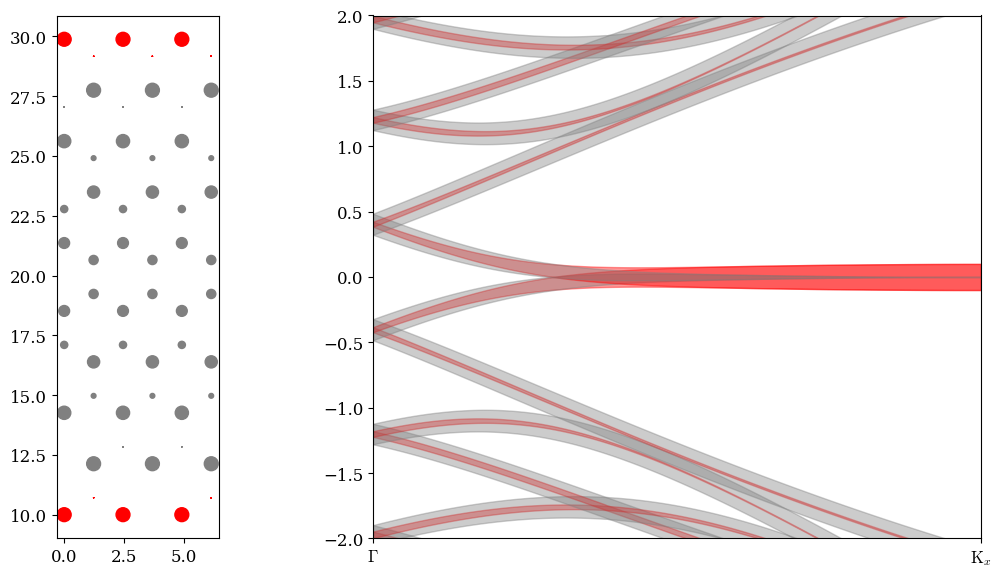

In [386]:
scale = 0.1
ylim = 2.

E = 0
vals, = np.where(np.isclose(energies, E, atol=1e-2))
Eidx = vals[0] 

norm = lambda M: (M - M.min()) / (M.max() - M.min()) * 100
fig, axes = plt.subplots(1,2, figsize=(12, 6))

axes[0].scatter(x[edge_idx], y[edge_idx], c='red', s=norm(pdos[edge_idx, Eidx]))
axes[0].scatter(x[bulk_idx], y[bulk_idx], c='grey', s=norm(pdos[bulk_idx, Eidx]))

# axes[1].plot(lk, eigvals, color='k', lw=1)
for band in range(ham.na):
    upper = eigvals[:, band] + (edge_weights[:, band]*scale)
    lower = eigvals[:, band] - (edge_weights[:, band]*scale)
    axes[1].fill_between(lk, lower, upper, color='r', 
                         alpha=0.4,
                         edgecolor='r')
    upper = eigvals[:, band] + (bulk_weights[:, band]*scale)
    lower = eigvals[:, band] - (bulk_weights[:, band]*scale)
    axes[1].fill_between(lk, lower, upper, color='grey', 
                         alpha=0.4,
                         edgecolor='grey')
    
axes[1].set_ylim(-ylim, ylim)
axes[1].set_xlim(lk[0], lk[-1])
axes[1].set_xticks(kt, kl)
axes[0].axis('scaled')
fig.tight_layout()